In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import clip
from PIL import Image
from PIL import ImageOps
import cv2

import numpy as np
import pandas as pd
import copy
import os
import glob

import datetime as dt
import time
from timethis import timethis
import subprocess
from common_params import parent_directory_images, parent_directory_url_csvs
from preprocess_data_fns import create_image_files_df, get_predicted_categories_clip, categorize_and_plot, categories


In [2]:
# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [25]:
# define the list of categories
# this needs to be selected carefully, similar to prompt engineering for LLMs


CAR_EXTERIOR_THRESHOLD = 0.7

output_filename = f'{parent_directory_url_csvs}df_clip_categorize.csv'
output_filename_rules = f'{parent_directory_url_csvs}df_clip_categorize_rules.csv'



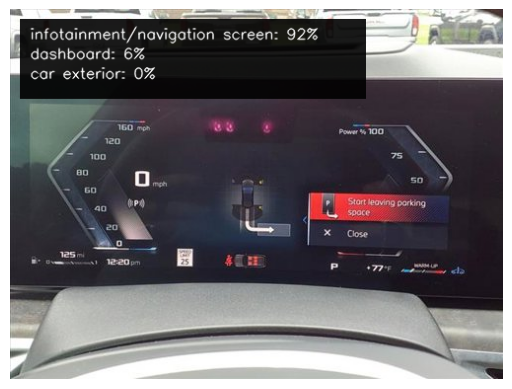

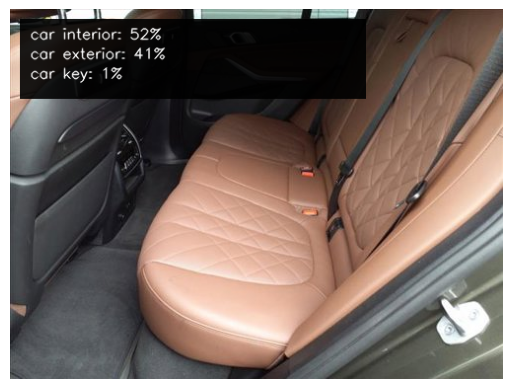

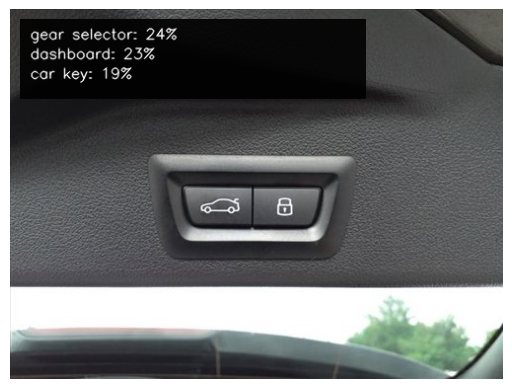

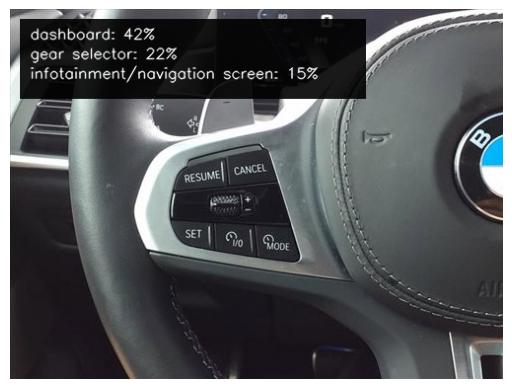

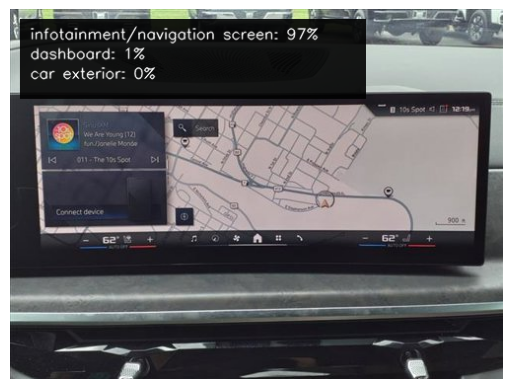

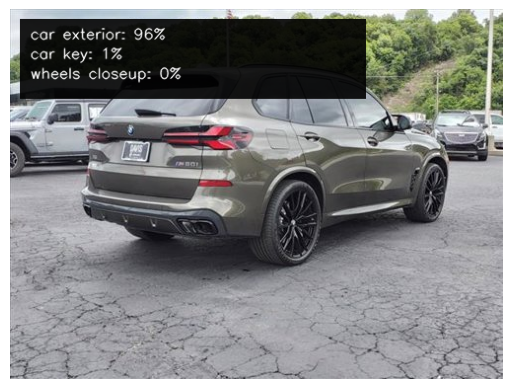

[<module 'matplotlib.pyplot' from '/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/matplotlib/pyplot.py'>,
 <module 'matplotlib.pyplot' from '/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/matplotlib/pyplot.py'>,
 <module 'matplotlib.pyplot' from '/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/matplotlib/pyplot.py'>,
 <module 'matplotlib.pyplot' from '/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/matplotlib/pyplot.py'>,
 <module 'matplotlib.pyplot' from '/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/matplotlib/pyplot.py'>,
 <module 'matplotlib.pyplot' from '/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/matplotlib/pyplot.py'>]

In [6]:
# demonstrate that CLIP does a reasonable job
files=sorted(glob.glob('/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-x5/vehicle_id-716406739/*.jpg'))
files=files[:6]

# categorize_and_plot(image_path=files[0], categories=categories)
list(map(
    lambda x: categorize_and_plot(x, categories),
    files
))

In [7]:

image_files_df = create_image_files_df()
image_files_df = image_files_df.drop_duplicates(subset=['filepath'])
image_files_df.sort_values(['make','model','vehicle_id','filename'],inplace=True)
image_files_df.reset_index(inplace=True,drop=True)
image_files_df.head()


25947


,filepath,filename,make,model,vehicle_id
0,/Users/levgolod/Projects/car_classifier/data/a...,20f1aa5ef85b48f7ac676a1e82147582.jpg,bmw,3-series,701932606
1,/Users/levgolod/Projects/car_classifier/data/a...,376e2b73f7e04c0abb53dbed174a7bc8.jpg,bmw,3-series,701932606
2,/Users/levgolod/Projects/car_classifier/data/a...,6f01890791f24dd69ccc70aff90cd73c.jpg,bmw,3-series,701932606
3,/Users/levgolod/Projects/car_classifier/data/a...,ac2d692d18f64c6b9eb4835d24bd42eb.jpg,bmw,3-series,701932606
4,/Users/levgolod/Projects/car_classifier/data/a...,b4ade0a7c1c5426496acf7b3d45eb8d5.jpg,bmw,3-series,701932606


In [8]:

# df2=image_files_df.head(25).copy(deep=True) # start w just a sample
df2=image_files_df.copy(deep=True)




In [9]:

iterprint = 100
for i in df2.index:
    if i % iterprint==0:
        message =\
f'''###########################################################
### Begin processing {i} of {len(image_files_df)} | {dt.datetime.now().replace(microsecond=0)}
###########################################################'''
        print(message) # second
        timestamp = int(time.time())
        filename_checkpoint = output_filename + f'-checkpoint.{timestamp}'
        df2.loc[:i+1, ].to_csv(filename_checkpoint, index=False)

    probs = get_predicted_categories_clip(
        image_path= image_files_df.loc[i, 'filepath'],
        categories=categories
    )
    top_category  = probs.head(1).index[0]
    probs_dict = dict(probs)
    is_car_exterior = probs_dict.get('car exterior',0) >= CAR_EXTERIOR_THRESHOLD
    df2.loc[i, 'is_car_exterior']=int(is_car_exterior)
    df2.loc[i, 'top_category']=str(top_category)
    df2.loc[i, 'probs_dict']=str(probs_dict)


df2.to_csv(output_filename, index=False)



###########################################################
### Begin processing 0 of 25947 | 2025-02-17 18:35:21
###########################################################
###########################################################
### Begin processing 10 of 25947 | 2025-02-17 18:35:32
###########################################################
###########################################################
### Begin processing 20 of 25947 | 2025-02-17 18:35:43
###########################################################
###########################################################
### Begin processing 30 of 25947 | 2025-02-17 18:35:53
###########################################################
###########################################################
### Begin processing 40 of 25947 | 2025-02-17 18:36:04
###########################################################
###########################################################
### Begin processing 50 of 25947 | 2025-02-17 18:36:15
###########

OSError: image file is truncated (2 bytes not processed)

In [11]:
## add try/except due to error in previous execution

iterprint = 100
for i in range(6414, len(df2)+1):
    if i % iterprint==0:
        message =\
f'''###########################################################
### Begin processing {i} of {len(image_files_df)} | {dt.datetime.now().replace(microsecond=0)}
###########################################################'''
        print(message) # second
        timestamp = int(time.time())
        filename_checkpoint = output_filename + f'-checkpoint.{timestamp}'
        df2.loc[:i+1, ].to_csv(filename_checkpoint, index=False)

    image_path= image_files_df.loc[i, 'filepath']
    try:
        probs = get_predicted_categories_clip(
            image_path= image_path,
            categories=categories
        )
        top_category  = probs.head(1).index[0]
        probs_dict = dict(probs)
        is_car_exterior = probs_dict.get('car exterior',0) >= CAR_EXTERIOR_THRESHOLD
        df2.loc[i, 'is_car_exterior']=int(is_car_exterior)
        df2.loc[i, 'top_category']=str(top_category)
        df2.loc[i, 'probs_dict']=str(probs_dict)
    except Exception as e:
        print(f'\nProblem with {i} {image_path}')
        print(e)





Problem with 6415 /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-ford/model-explorer/vehicle_id-737083924/26b0c45a083d403ba5ee19be3af969f7.jpg
image file is truncated (2 bytes not processed)
###########################################################
### Begin processing 6500 of 25947 | 2025-02-17 20:47:34
###########################################################
###########################################################
### Begin processing 6600 of 25947 | 2025-02-17 20:49:27
###########################################################
###########################################################
### Begin processing 6700 of 25947 | 2025-02-17 20:51:34
###########################################################
###########################################################
### Begin processing 6800 of 25947 | 2025-02-17 20:53:22
###########################################################
###########################################################
### Begin p

KeyError: 25947

In [13]:
df2.to_csv(output_filename, index=False)

In [24]:
# clean up intermediate files
# !find '/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_metadata/' -type f -name '*checkpoint*' -delete

In [9]:
df = pd.read_csv(output_filename)
print(df.shape)
df.head()

(25947, 8)


,filepath,filename,make,model,vehicle_id,is_car_exterior,top_category,probs_dict
0,/Users/levgolod/Projects/car_classifier/data/a...,20f1aa5ef85b48f7ac676a1e82147582.jpg,bmw,3-series,701932606,0.0,car exterior,"{'car exterior': 0.44714555, 'car interior': 0..."
1,/Users/levgolod/Projects/car_classifier/data/a...,376e2b73f7e04c0abb53dbed174a7bc8.jpg,bmw,3-series,701932606,1.0,car exterior,"{'car exterior': 0.8252363, 'advertisement': 0..."
2,/Users/levgolod/Projects/car_classifier/data/a...,6f01890791f24dd69ccc70aff90cd73c.jpg,bmw,3-series,701932606,0.0,dashboard,"{'dashboard': 0.4605527, 'steering wheel': 0.2..."
3,/Users/levgolod/Projects/car_classifier/data/a...,ac2d692d18f64c6b9eb4835d24bd42eb.jpg,bmw,3-series,701932606,1.0,car exterior,"{'car exterior': 0.7926975, 'advertisement': 0..."
4,/Users/levgolod/Projects/car_classifier/data/a...,b4ade0a7c1c5426496acf7b3d45eb8d5.jpg,bmw,3-series,701932606,1.0,car exterior,"{'car exterior': 0.96773624, 'advertisement': ..."


In [10]:
df['is_car_exterior'].mean()

0.2902404198664763

In [11]:
df.loc[df['is_car_exterior']==0, 'top_category'].value_counts()

top_category
car interior                      3928
car exterior                      3459
infotainment/navigation screen    2748
gear selector                     2575
advertisement                     1839
dashboard                         1016
wheels closeup                     954
steering wheel                     642
car key                            602
engine bay                         351
paperwork                          130
moonroof                           105
wireless charger                    33
gauge cluster                       10
Name: count, dtype: int64

In [12]:
# inspect some of the images where the top category is 'car exterior' but probability < 70%
mask = ((df['is_car_exterior']==0) & (df['top_category']=='car exterior'))
print(mask.sum(), mask.mean())
df.loc[mask, ].sample(frac=1).head()

3459 0.13331020927274828


,filepath,filename,make,model,vehicle_id,is_car_exterior,top_category,probs_dict
23513,/Users/levgolod/Projects/car_classifier/data/a...,7159d3f09c6442668db95da38bab42a3.jpg,toyota,tacoma,737716991,0.0,car exterior,"{'car exterior': 0.5035889, 'engine bay': 0.40..."
2085,/Users/levgolod/Projects/car_classifier/data/a...,f938391d44134050a2661090a903523e.jpg,bmw,4-series,734681209,0.0,car exterior,"{'car exterior': 0.24436176, 'infotainment/nav..."
6181,/Users/levgolod/Projects/car_classifier/data/a...,1ece58df93c0433d81431483d34dd0af.jpg,ford,explorer,736472749,0.0,car exterior,"{'car exterior': 0.59614885, 'car key': 0.1441..."
3146,/Users/levgolod/Projects/car_classifier/data/a...,e1d22a7c0a5a487595ad2d4df92ecce7.jpg,bmw,x5,729768750,0.0,car exterior,"{'car exterior': 0.40419236, 'car interior': 0..."
9027,/Users/levgolod/Projects/car_classifier/data/a...,066f71168304460790086cc69caffe02.jpg,ford,f150,735979767,0.0,car exterior,"{'car exterior': 0.67433476, 'advertisement': ..."


In [13]:
# remove rows w null values
print(df['probs_dict'].isnull().mean(), df['probs_dict'].isnull().sum())
df=df.loc[df['probs_dict'].notnull(), ].reset_index(drop=True)

0.0013103634331521948 34


In [14]:
df['probs_dict2'] = df['probs_dict'].fillna('{}').apply(eval)

In [15]:
# get the probability of car exterior image assigned by CLIP
df['pct_exterior'] = df['probs_dict2'].apply(
    lambda x: round(x.get('car exterior', 0),2)
)
print(df['pct_exterior'].describe())

count    25913.000000
mean         0.397920
std          0.350594
min          0.000000
25%          0.070000
50%          0.280000
75%          0.770000
max          1.000000
Name: pct_exterior, dtype: float64


In [49]:
files='''/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-honda/model-civic/vehicle_id-738635906/ca62907752674c64b5236783110f9da4.jpg
/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-ford/model-explorer/vehicle_id-737403191/0de87636cf9d45959ffc41e5b52face2.jpg
/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-toyota/model-tacoma/vehicle_id-736690161/63f69464cf6e415f93b1e3ab983df584.jpg
/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-ford/model-explorer/vehicle_id-738651921/d627bc9886124262a4c011a2b91b4879.jpg'''.split('\n')
#
# list(map(
#     lambda x: categorize_and_plot(x, categories),
#     files
# ))

In [ ]:
# these are actually car exteriors but % below 70
# maybe the right threshold was 50 ?
# ca62907752674c64b5236783110f9da4.jpg

# it looks like it matters what the #2 category is


In [16]:
df['is_exterior']=0
df['reason'] = ''
mask_gt70 = df['pct_exterior'] >= 0.70
mask_gt70.mean()
df.loc[mask_gt70, 'reason'] = 'pct_exterior>=70'
df.loc[mask_gt70, 'is_exterior'] = 1
print(df['is_exterior'].mean())
print(df['reason'].value_counts())


0.2921699533052908
reason
                    18342
pct_exterior>=70     7571
Name: count, dtype: int64


In [18]:

df['top3_categories']= df['probs_dict2'].head().apply(lambda x: [y[0] for y in sorted(x.items(), key=lambda x: -x[1])[:3]])
df['top3_categories'].head()

0            [car exterior, car interior, car key]
1     [car exterior, advertisement, gear selector]
2       [dashboard, steering wheel, gear selector]
3     [car exterior, advertisement, gear selector]
4    [car exterior, advertisement, wheels closeup]
Name: top3_categories, dtype: object

In [19]:
# if car exterior >= 50 and 2nd category is advertisement , then it is likely a car exterior
mask_advert = (
    (df['pct_exterior'].between(0.50,0.70))
    # (df['pct_exterior'].between(0.30,0.50))
    & (df['probs_dict2'].apply(lambda x: sorted(x.items(), key=lambda x: -x[1])[1][0]) == 'advertisement')
)
print(mask_advert.mean())

mask_advert = (
    (df['pct_exterior'].between(0.40,0.70))
    & (
        (df['probs_dict2'].apply(lambda x: sorted(x.items(), key=lambda x: -x[1])[1][0]) == 'advertisement') |
        (df['top_category']=='advertisement')
    )

)
print(mask_advert.mean())


df.loc[(mask_advert & (df['reason']=='')), 'reason'] = 'advert & pct_exterior>=50'
df.loc[mask_advert, 'is_exterior'] = 1
print(df['is_exterior'].mean())
print(df['reason'].value_counts())

0.03677690734380427
0.04850847065179639
0.33863311851194383
reason
                             17138
pct_exterior>=70              7571
advert & pct_exterior>=50     1204
Name: count, dtype: int64


(31, 14)


b8aa4577b1294c7b875b1088844de63e.jpg 40.0%



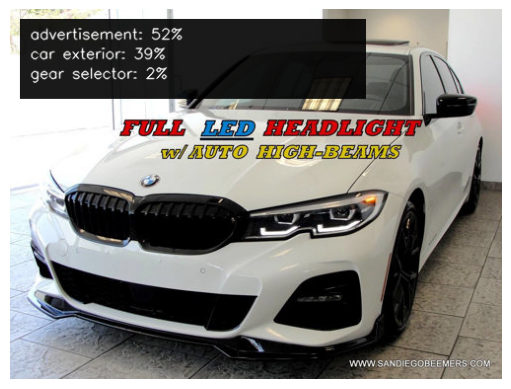



3fa3a4239b0a4d7693642f0f8efb6183.jpg 41.0%



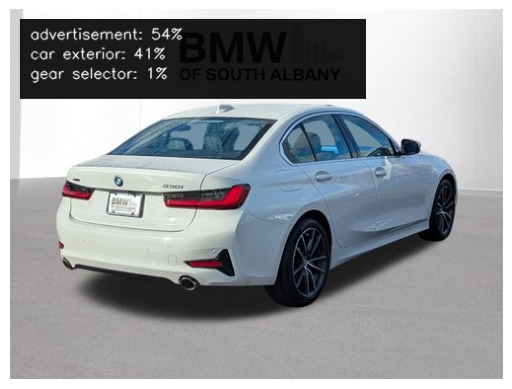



a364806167b74b54be97fbe9d7511b4a.jpg 42.0%



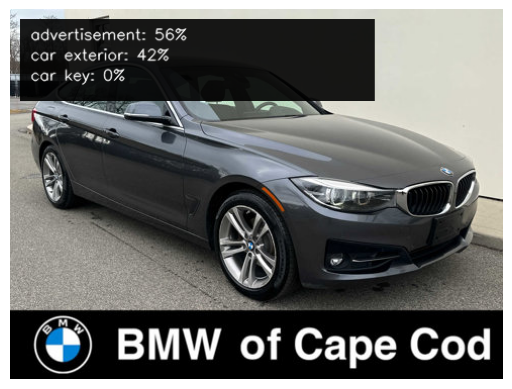



e2b53b10d6d847ad8cb962e6eb07a51a.jpg 43.0%



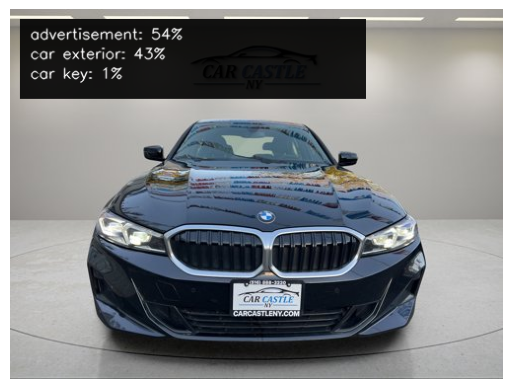



65b9c8cb3af64c7581442421e0420839.jpg 44.0%



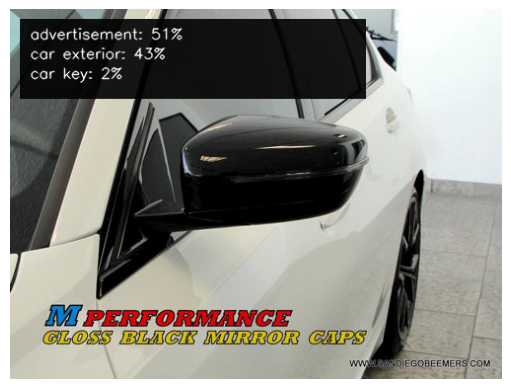

In [93]:
df_dedup = df.loc[mask_advert, ].drop_duplicates(subset=['pct_exterior']).sort_values(['pct_exterior'],ascending=False).reset_index(drop=True)
df_dedup = df.loc[mask_advert, ].drop_duplicates(subset=['pct_exterior']).sort_values(['pct_exterior'],ascending=True).reset_index(drop=True)
print(df_dedup.shape)
for record in df_dedup.to_dict('records')[:5]:
# for record in df_dedup.to_dict('records'):
    message=f'''

{record['filename']} {record['pct_exterior']*100}%
'''
    print(message)
    categorize_and_plot(record['filepath'], categories)



In [26]:
print(output_filename_rules)
df.to_csv(output_filename_rules, index=False)

/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_metadata/df_clip_categorize_rules.csv


## Check for false positives by inspecting the records that are marked as exteriors

(61, 13)


344a4bc9e5414babbf1f33838bf91e38.jpg 40.0%



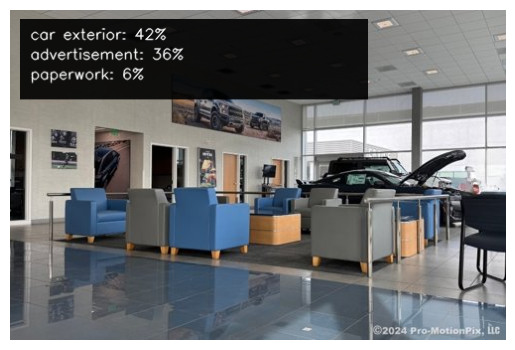



7863c4e77b45465491fa4fe0f68b0b21.jpg 41.0%



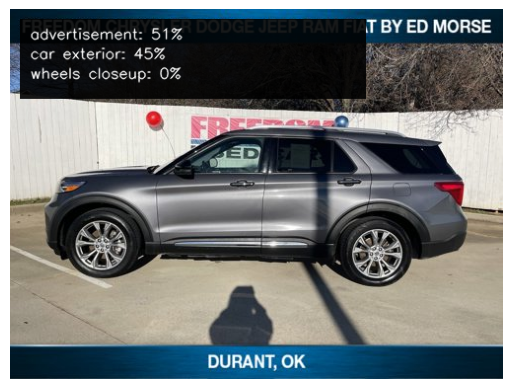



73e2c713bb0b4fb8bf925de56981102c.jpg 42.0%



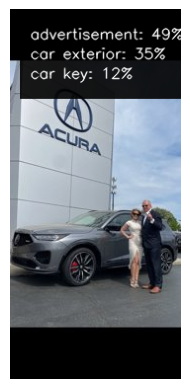



d74f719291ff4e67997f727b1990e755.jpg 43.0%



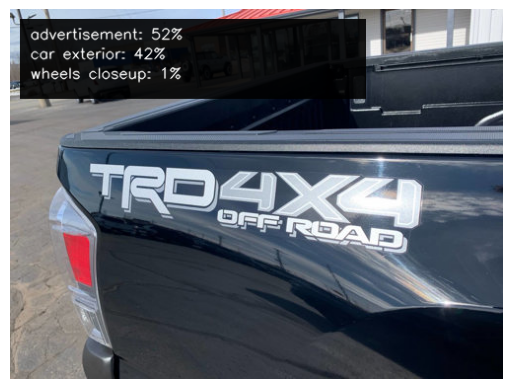



413820da8a1843bdbef3aff9f2649c93.jpg 44.0%



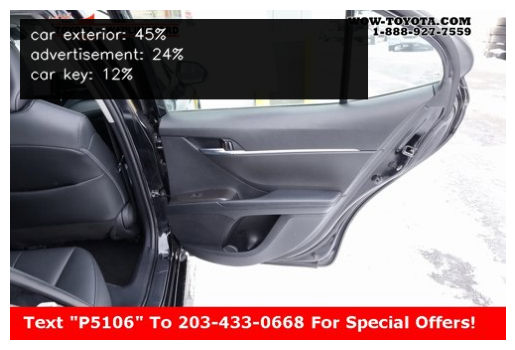

In [20]:
# let's pick a new threshold by eyeballing
df_dedup = df.loc[df['is_exterior']==1, ].sample(frac=1).drop_duplicates(subset=['pct_exterior']).sort_values(['pct_exterior'],ascending=False).reset_index(drop=True)
df_dedup = df.loc[df['is_exterior']==1, ].sample(frac=1).drop_duplicates(subset=['pct_exterior']).sort_values(['pct_exterior'],ascending=True).reset_index(drop=True)
print(df_dedup.shape)
records = df_dedup.to_dict('records')
records = records[:5]

for record in records:
    message=f'''

{record['filename']} {record['pct_exterior']*100}%
'''
    print(message)
    categorize_and_plot(record['filepath'], categories)



In [ ]:
## False positive - this is actually a door !!# 7aff2d04c01e404591f3b4767d134d76.jpg

# 7c06e566a060474581b61a01ba6efccc.jpg - this is coming in as a negative
# 73bb5ae0a7a54c0aa57dff00c861eca7 badge

## Check for false negatives

(70, 13)


8ee0f5da55234f29a923548c4d0f3cac.jpg 69.0%



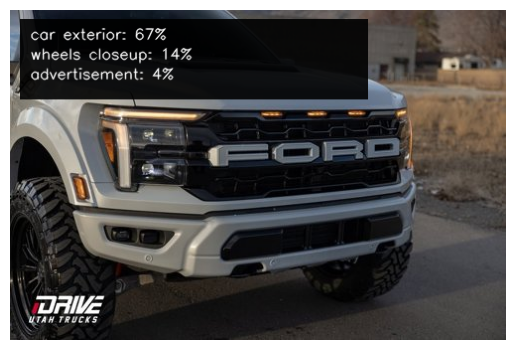



5f17ca4f6d2b49289693a816458ecd82.jpg 68.0%



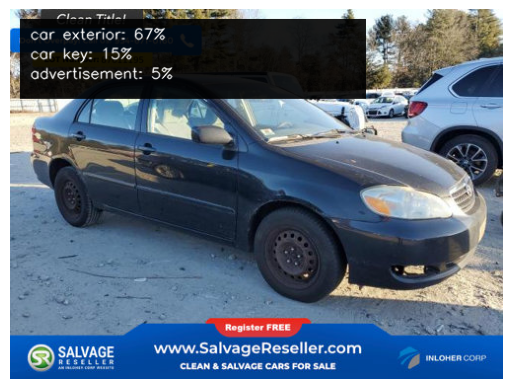



f1a2ddf81c8d4239941446e0ef5b0329.jpg 67.0%



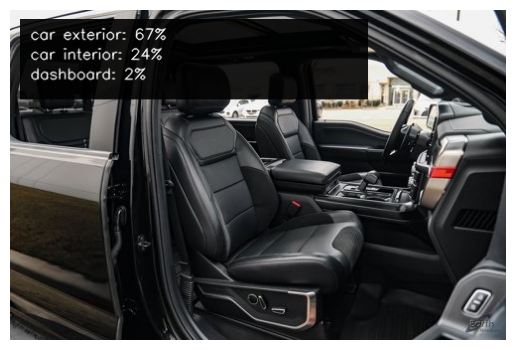



ebb7cdb24cb84dfeaa024f3bb964c215.jpg 66.0%



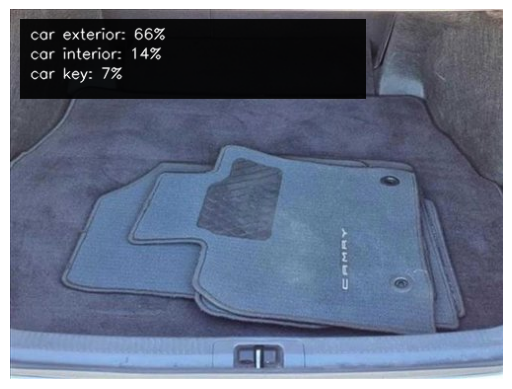



5b7a8deb845f4c6697f94253f443b695.jpg 65.0%



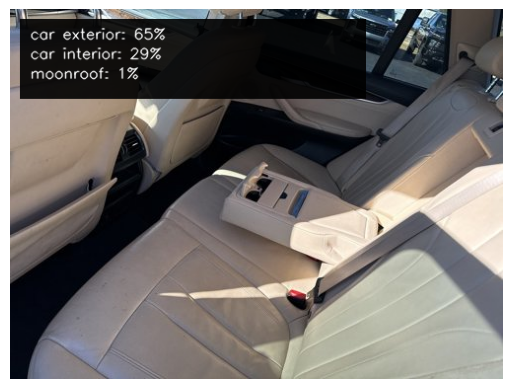

In [21]:
df_dedup = df.loc[df['is_exterior']==0, ].sample(frac=1).drop_duplicates(subset=['pct_exterior']).sort_values(['pct_exterior'],ascending=False).reset_index(drop=True)
print(df_dedup.shape)
records = df_dedup.to_dict('records')
records = records[:5]

for record in records:
    message=f'''

{record['filename']} {record['pct_exterior']*100}%
'''
    print(message)
    categorize_and_plot(record['filepath'], categories)

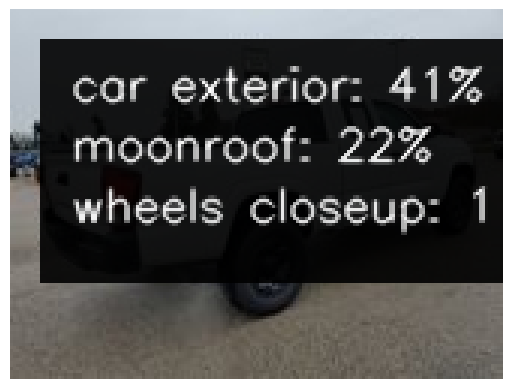

(123, 164, 3)

In [22]:
## There are not too many false negatives but here is one of them
# 2f8da6e615624dcba09c22b1ec1e4479

image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-toyota/model-tacoma/vehicle_id-730197477/2f8da6e615624dcba09c22b1ec1e4479.jpg'
categorize_and_plot(image_path, categories)

image = cv2.imread(image_path)
image.shape

